# GiBUU Interaction Model Training

This notebook trains the `GiBUUInteractionModel` (Encoder-Decoder Transformer) for predicting particle changes during interactions.

**Workflow:**
1. Load processed NPZ data from `GiBUU_dataprep.ipynb`
2. Prepare data for training (call `prepare_interaction_data`)
3. Configure model and training parameters
4. Train model with PyTorch Lightning
5. Test trained model

**Model Architecture:**
- Encoder-Decoder Transformer architecture
- Encoder processes input timestep (t1)
- Decoder generates output timestep (t2) with teacher forcing
- Bidirectional attention (particles in same timestep can attend to each other)
- Predicts particle types and features

**Output:**
- Trained model saved in `lightning_logs/`
- Checkpoints for resuming training or inference

## Step 1: Imports

In [28]:
# Enable auto-reload of modules
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import lightning.pytorch as pl
import numpy as np
import glob
from pathlib import Path
from typing import List, Tuple, Dict

# Import from gibuu_transformer package
from gibuu_transformer import (
    GiBUUInteractionModel,
    GiBUUInteractionLightning,
    gibuu_interaction_loss,
    prepare_interaction_data,
    load_pairs_from_npz,
    FEATS_MEAN,
    FEATS_SIGMA,
    EOS_STEP_TOKEN,
    PAD_TOKEN,
    START_TOKEN,
    list_checkpoints,
    find_checkpoint
)

print(f"✓ Imports successful!")
print(f"  PyTorch version: {torch.__version__}")
print(f"  Lightning version: {pl.__version__}")
print(f"  Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"\nFeature normalization constants loaded:")
print(f"  FEATS_MEAN: {FEATS_MEAN}")
print(f"  FEATS_SIGMA: {FEATS_SIGMA}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Imports successful!
  PyTorch version: 2.8.0+cu128
  Lightning version: 2.5.2
  Device: cuda

Feature normalization constants loaded:
  FEATS_MEAN: [0.0, 0.0, 6.13, 0.42, 0.0, 0.0, 0.5]
  FEATS_SIGMA: [5.89, 5.89, 9.33, 0.975, 0.304, 0.304, 1.123]


## Step 2: Load NPZ Data

Load preprocessed data from `GiBUU_dataprep.ipynb` output.

In [68]:
# Configuration
NPZ_PATH = "/exp/dune/data/users/yinrui/GiBUU/GPTdata/processed_data"
JOB_ID = 990
MAX_PAIRS = None  # Set to a number for quick testing, None to load all

# Load interaction pairs (pairs with changes)
with_file = Path(NPZ_PATH) / "npz_with_changes" / f"pairs_with_changes_{JOB_ID:06d}.npz"

with_changes_files = [str(with_file)] if with_file.exists() else []

print(f"Loading Job {JOB_ID:06d}...")
print(f"  Interaction file: {with_file.name} {'✓' if with_file.exists() else '✗'}")

# Load pairs with changes (interactions)
pairs_with_changes = load_pairs_from_npz(with_changes_files, max_pairs=MAX_PAIRS, random_subset=True)

print(f"\n✓ Data loaded: {len(pairs_with_changes)} interaction pairs")
if MAX_PAIRS is not None:
    print(f"  (Limited to {MAX_PAIRS} pairs for quick testing)")

Loading Job 000990...
  Interaction file: pairs_with_changes_000990.npz ✓

✓ Data loaded: 147408 interaction pairs


## Step 3: Prepare Data for Training

Convert pairs to format expected by the interaction model (encoder-decoder).

In [69]:
# Prepare interaction data
interaction_data = prepare_interaction_data(
    pairs_with_changes,  # Pass as positional argument
    stats_path=None  # Uses constants from constants.py
)

print("✓ Data prepared for training:")
print(f"  Total pairs: {len(interaction_data['input_encoded_ids'])}")

# Show example
idx = 0
print(f"\nExample pair {idx}:")
print(f"  Input IDs: {interaction_data['input_encoded_ids'][idx][:]}... ({len(interaction_data['input_encoded_ids'][idx])} particles)")
print(f"  Output IDs: {interaction_data['output_encoded_ids'][idx][:]}... ({len(interaction_data['output_encoded_ids'][idx])} particles)")

Preparing 147408 interaction pairs for training...
✓ Prepared 147408 interaction pairs
  Features: [x, y, z, KE, Px, Py, Pz] where KE = E - m
  Normalization: (feature - FEATS_MEAN) / FEATS_SIGMA
✓ Data prepared for training:
  Total pairs: 147408

Example pair 0:
  Input IDs: [1153, 1153, 1126, 1025, 1025, 1025, 1025, 1153, 1153, 1025, 1025, 1025, 1153, 1025, 1153, 1125, 1024]... (17 particles)
  Output IDs: [2048, 1153, 1153, 1126, 1025, 1025, 1025, 1025, 1153, 1153, 1025, 1025, 1025, 1153, 1153, 1025, 1125, 1024]... (18 particles)


## Step 4: Create Dataset and DataLoader

In [70]:
class TimeStepPairDataset(Dataset):
    """
    Dataset for time step pairs with variable-length sequences.
    """
    def __init__(self, pair_data):
        self.input_encoded_ids = pair_data['input_encoded_ids']
        self.input_particle_feats = pair_data['input_particle_feats']
        self.output_encoded_ids = pair_data['output_encoded_ids']
        self.output_particle_feats = pair_data['output_particle_feats']
    
    def __len__(self):
        return len(self.input_encoded_ids)
    
    def __getitem__(self, idx):
        return {
            'input_encoded_ids': self.input_encoded_ids[idx],
            'input_particle_feats': self.input_particle_feats[idx],
            'output_encoded_ids': self.output_encoded_ids[idx],
            'output_particle_feats': self.output_particle_feats[idx]
        }

def collate_timestep_pairs(batch):
    """
    Custom collate function for variable-length time step pairs.
    Pads each batch to the maximum length within that batch.
    """
    # Extract all sequences from batch
    input_ids_list = [item['input_encoded_ids'] for item in batch]
    input_feats_list = [item['input_particle_feats'] for item in batch]
    output_ids_list = [item['output_encoded_ids'] for item in batch]
    output_feats_list = [item['output_particle_feats'] for item in batch]
    
    # Find max lengths in this batch
    max_input_len = max(len(ids) for ids in input_ids_list)
    max_output_len = max(len(ids) for ids in output_ids_list)
    max_seq_len = max(max_input_len, max_output_len)
    
    batch_size = len(batch)
    
    # Pad input sequences
    input_encoded_ids_padded = []
    input_particle_feats_padded = []
    input_padding_mask_list = []
    
    for ids, feats in zip(input_ids_list, input_feats_list):
        pad_len = max_seq_len - len(ids)
        if pad_len > 0:
            ids_padded = ids + [PAD_TOKEN] * pad_len
            feats_padded = feats + [[0.0] * 7] * pad_len
            padding_mask = [False] * len(ids) + [True] * pad_len
        else:
            ids_padded = ids
            feats_padded = feats
            padding_mask = [False] * len(ids)
        
        input_encoded_ids_padded.append(ids_padded)
        input_particle_feats_padded.append(feats_padded)
        input_padding_mask_list.append(padding_mask)
    
    # Pad output sequences
    output_encoded_ids_padded = []
    output_particle_feats_padded = []
    output_padding_mask_list = []
    
    for ids, feats in zip(output_ids_list, output_feats_list):
        pad_len = max_seq_len - len(ids)
        if pad_len > 0:
            ids_padded = ids + [PAD_TOKEN] * pad_len
            feats_padded = feats + [[0.0] * 7] * pad_len
            padding_mask = [False] * len(ids) + [True] * pad_len
        else:
            ids_padded = ids
            feats_padded = feats
            padding_mask = [False] * len(ids)
        
        output_encoded_ids_padded.append(ids_padded)
        output_particle_feats_padded.append(feats_padded)
        output_padding_mask_list.append(padding_mask)
    
    # Convert to tensors
    return {
        'input_encoded_ids': torch.tensor(input_encoded_ids_padded, dtype=torch.long),
        'input_particle_feats': torch.tensor(input_particle_feats_padded, dtype=torch.float32),
        'input_padding_mask': torch.tensor(input_padding_mask_list, dtype=torch.bool),
        'output_encoded_ids': torch.tensor(output_encoded_ids_padded, dtype=torch.long),
        'output_particle_feats': torch.tensor(output_particle_feats_padded, dtype=torch.float32),
        'output_padding_mask': torch.tensor(output_padding_mask_list, dtype=torch.bool)
    }

# Create dataset
dataset = TimeStepPairDataset(interaction_data)

# Split into train/val
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"✓ Datasets created:")
print(f"  Train: {len(train_dataset)} pairs")
print(f"  Val: {len(val_dataset)} pairs")

✓ Datasets created:
  Train: 117926 pairs
  Val: 29482 pairs


## Step 5: Configure and Train Model


In [81]:
# Load config from file
import json
with open('config.json', 'r') as f:
    cfg = json.load(f)

# Override settings for interaction model
cfg['type_loss_weight'] = 1.0
cfg['feat_loss_weight'] = 1.0
cfg['lr'] = 1e-4
cfg['weight_decay'] = 1e-5

# Training hyperparameters
BATCH_SIZE = 32
MAX_EPOCHS = 500
LOG_EVERY_N_STEPS = 100
EXPERIMENT_NAME = "gibuu_interaction"

# Resume training configuration
RESUME_TRAINING = True
CHECKPOINT_PATH = None
CHECKPOINT_NAME = "last.ckpt"

# Update config with trainer settings
cfg['trainer'] = {
    'batch_size': BATCH_SIZE,
    'max_epochs': MAX_EPOCHS,
    'log_every_n_steps': LOG_EVERY_N_STEPS
}

print("✓ Configuration set:")
print(f"  Model: GiBUUInteractionModel (Encoder-Decoder Transformer)")
print(f"  Learning rate: {cfg['lr']}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {MAX_EPOCHS}")
print(f"  Resume training: {RESUME_TRAINING}")

✓ Configuration set:
  Model: GiBUUInteractionModel (Encoder-Decoder Transformer)
  Learning rate: 0.0001
  Batch size: 32
  Max epochs: 500
  Resume training: True


In [82]:
# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_timestep_pairs,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_timestep_pairs,
    num_workers=4,
    pin_memory=True
)

print(f"✓ DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

✓ DataLoaders created:
  Train batches: 3686
  Val batches: 922


In [85]:
# Create model (with resume support)
if RESUME_TRAINING:
    CHECKPOINT_PATH = find_checkpoint(
        experiment_name=EXPERIMENT_NAME,
        checkpoint_path=CHECKPOINT_PATH,
        checkpoint_name=CHECKPOINT_NAME
    )
    
    if CHECKPOINT_PATH is not None:
        model = GiBUUInteractionLightning.load_from_checkpoint(CHECKPOINT_PATH, cfg=cfg)
    else:
        print("⚠ No checkpoint found, starting new training")
        RESUME_TRAINING = False
        model = GiBUUInteractionLightning(cfg)
else:
    print("✓ Starting new training")
    model = GiBUUInteractionLightning(cfg)

# Create trainer
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='auto',
    devices='auto',
    log_every_n_steps=LOG_EVERY_N_STEPS,
    
    # Checkpointing
    callbacks=[
        pl.callbacks.ModelCheckpoint(
            dirpath=f'lightning_logs/{EXPERIMENT_NAME}/checkpoints',
            filename='model-{epoch:02d}-{val_loss:.4f}',
            monitor='val_loss',
            mode='min',
            save_top_k=3,
            save_last=True
        ),
        pl.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            mode='min',
            verbose=True
        )
    ],
    
    # Logging
    logger=pl.loggers.CSVLogger(
        save_dir='lightning_logs',
        name=EXPERIMENT_NAME
    )
)

print("✓ Trainer created")
print(f"  Logs will be saved to: lightning_logs/{EXPERIMENT_NAME}/")
print(f"  Checkpoints will be saved to: lightning_logs/{EXPERIMENT_NAME}/checkpoints/")

✓ Using specified checkpoint: lightning_logs/gibuu_interaction/checkpoints/last.ckpt


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


✓ Trainer created
  Logs will be saved to: lightning_logs/gibuu_interaction/
  Checkpoints will be saved to: lightning_logs/gibuu_interaction/checkpoints/


In [86]:
# Train!
if RESUME_TRAINING:
    print(f"Resuming training from checkpoint...\n")
    trainer.fit(model, train_loader, val_loader, ckpt_path=CHECKPOINT_PATH)
else:
    print("Starting training from scratch...\n")
    trainer.fit(model, train_loader, val_loader)

print("\n✓ Training complete!")
print(f"  Best model checkpoint: {trainer.checkpoint_callback.best_model_path}")
print(f"  Last checkpoint: {trainer.checkpoint_callback.last_model_path}")

Restoring states from the checkpoint path at lightning_logs/gibuu_interaction/checkpoints/last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type                  | Params | Mode 
-------------------------------------------------------
0 | net  | GiBUUInteractionModel | 261 K  | train
-------------------------------------------------------
261 K     Trainable params
0         Non-trainable params
261 K     Total params
1.047     Total estimated model params size (MB)
113       Modules in train mode
0         Modules in eval mode


Resuming training from checkpoint...



Restored all states from the checkpoint at lightning_logs/gibuu_interaction/checkpoints/last.ckpt


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 11 records. Best score: 0.257. Signaling Trainer to stop.



✓ Training complete!
  Best model checkpoint: /home/yinrui/GiBUU_viz/lightning_logs/gibuu_interaction/checkpoints/model-epoch=162-val_loss=0.2566.ckpt
  Last checkpoint: /home/yinrui/GiBUU_viz/lightning_logs/gibuu_interaction/checkpoints/last.ckpt


Loading metrics from: lightning_logs/gibuu_interaction/combined.csv
Columns: ['epoch', 'step', 'train_feat_loss', 'train_loss', 'train_type_loss', 'val_feat_loss', 'val_loss', 'val_type_loss']
✓ Loss curves plotted for interaction model

FINAL LOSS VALUES (Epoch 174):
  val_loss                      : 0.327271
  val_type_loss                 : 0.215374
  val_feat_loss                 : 0.111897


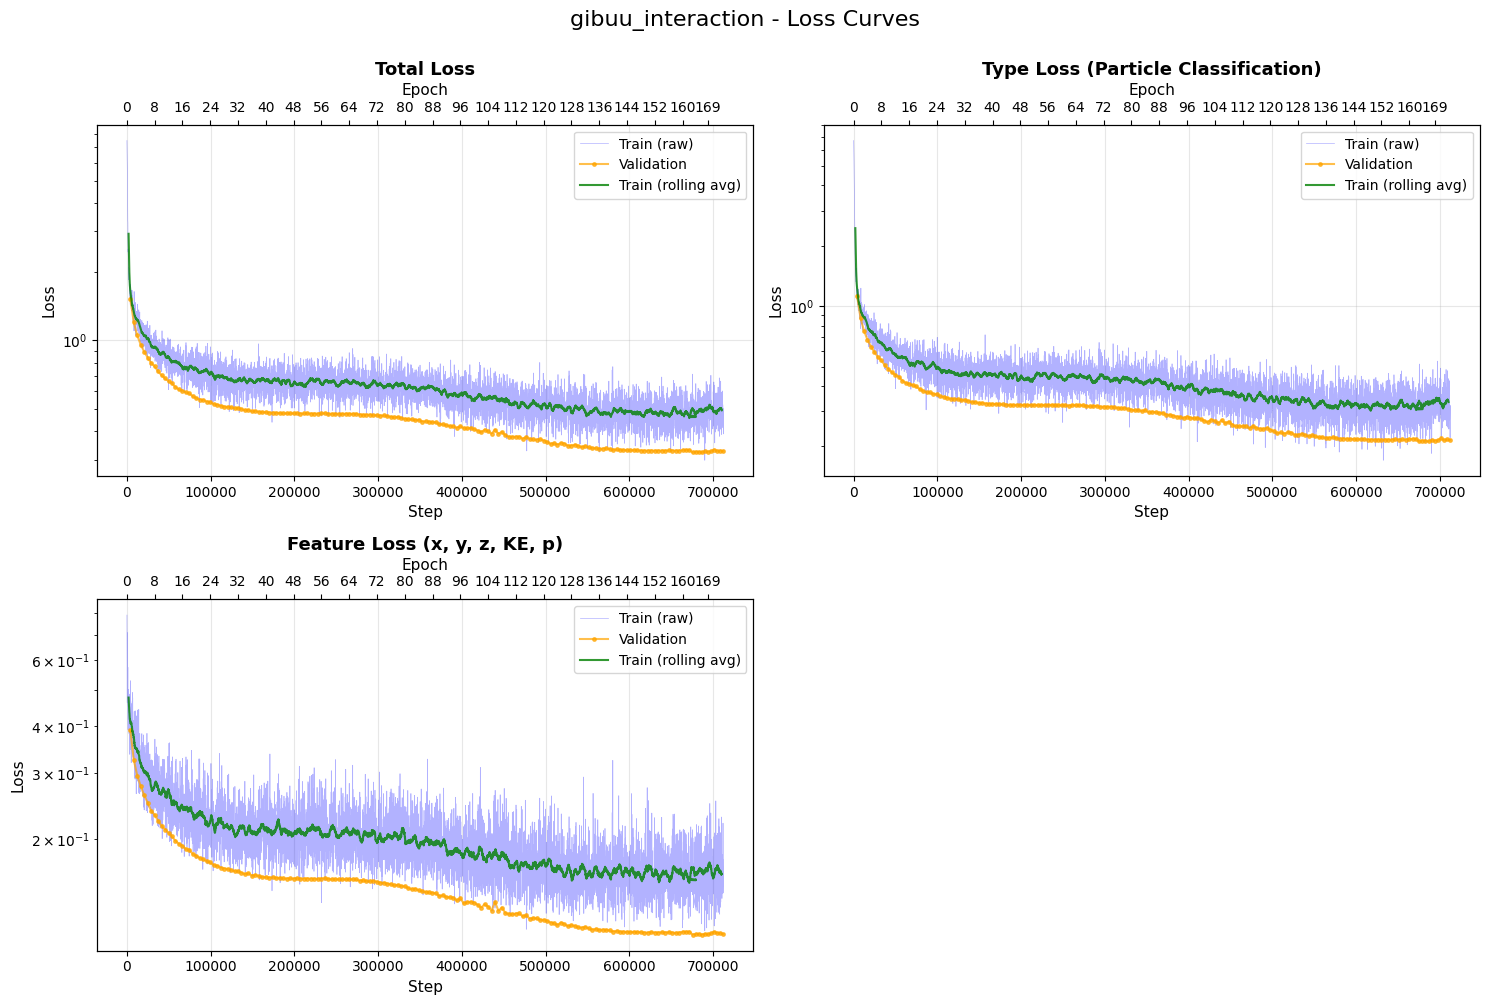

In [87]:
### Plot Loss Curves
from gibuu_transformer import plot_loss_curves
import matplotlib.pyplot as plt
import pandas as pd

EXPERIMENT_NAME = "gibuu_interaction"
COMBINE_CSV = True
if COMBINE_CSV:
    csv_idx_list = [0, 1, 2, 3, 4] # modify the list
    csv_path = f"lightning_logs/{EXPERIMENT_NAME}/combined.csv"
    dfs = [pd.read_csv(f'lightning_logs/{EXPERIMENT_NAME}/version_{i}/metrics.csv') for i in csv_idx_list]
    combined = pd.concat(dfs, ignore_index=True)
    combined.to_csv(csv_path, index=False)
else:
    csv_idx = 0 # modify the index
    csv_path = f"lightning_logs/{EXPERIMENT_NAME}/version_{csv_idx}/metrics.csv"

# Option 2: Plot from combined CSV (if you've combined multiple versions)
# csv_path = f"lightning_logs/{EXPERIMENT_NAME}/combined.csv"

fig, axes = plot_loss_curves(
    csv_path=csv_path,
    mode='interaction',
    figsize=(15, 10),
    title=f'{EXPERIMENT_NAME} - Loss Curves',
    logy=True
)

if fig is not None:
    plt.show()

---

## Test

Load trained model and test sample.

In [88]:
### Load Best Checkpoint

#checkpoint_path = trainer.checkpoint_callback.best_model_path
checkpoint_path = "lightning_logs/gibuu_interaction/checkpoints/last.ckpt"

model_loaded = GiBUUInteractionLightning.load_from_checkpoint(checkpoint_path)
model_loaded.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_loaded.to(device)

print(f"✓ Model loaded from: {checkpoint_path}")

✓ Model loaded from: lightning_logs/gibuu_interaction/checkpoints/last.ckpt


In [55]:
### Load Test Sample

# Configuration for test sample
TEST_SAMPLE_SIZE = 10000  # Number of pairs to load for testing

# Option 1: Use a subset of the training sample (COMMENTED OUT)
'''import random
random.seed(42)
test_indices = random.sample(range(len(train_dataset)), min(TEST_SAMPLE_SIZE, len(train_dataset)))
test_subset = torch.utils.data.Subset(train_dataset, test_indices)
test_loader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_timestep_pairs,
    num_workers=0,  # Set to 0 for testing
    pin_memory=False
)
print(f"✓ Test sample loaded from training data: {len(test_subset)} pairs")'''

# Option 2: Load test sample from NPZ file with TEST_JOB_ID
TEST_JOB_ID = 1000
test_file = Path(NPZ_PATH) / "npz_with_changes" / f"pairs_with_changes_{TEST_JOB_ID:06d}.npz"
test_files = [str(test_file)] if test_file.exists() else []

if not test_files:
    print(f"⚠ Test file not found: {test_file}")
    print("  Falling back to validation loader...")
    test_loader = val_loader
else:
    print(f"Loading test sample from Job {TEST_JOB_ID:06d}...")
    print(f"  Test file: {test_file.name} {'✓' if test_file.exists() else '✗'}")
    
    # Load test pairs
    test_pairs = load_pairs_from_npz(test_files, max_pairs=TEST_SAMPLE_SIZE, random_subset=True)
    
    if len(test_pairs) == 0:
        print("⚠ No test pairs loaded, falling back to validation loader...")
        test_loader = val_loader
    else:
        print(f"✓ Test pairs loaded: {len(test_pairs)} pairs")
        
        # Prepare test data
        test_data = prepare_interaction_data(
            test_pairs,
            stats_path=None  # Uses constants from constants.py
        )
        
        # Create test dataset and loader
        test_dataset = TimeStepPairDataset(test_data)
        test_loader = DataLoader(
            test_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            collate_fn=collate_timestep_pairs,
            num_workers=0,  # Set to 0 for testing
            pin_memory=False
        )
        
        print(f"✓ Test dataset created: {len(test_dataset)} pairs")
        print(f"  Test batches: {len(test_loader)}")


Loading test sample from Job 001000...
  Test file: pairs_with_changes_001000.npz ✓
✓ Test pairs loaded: 10000 pairs
Preparing 10000 interaction pairs for training...
✓ Prepared 10000 interaction pairs
  Features: [x, y, z, KE, Px, Py, Pz] where KE = E - m
  Normalization: (feature - FEATS_MEAN) / FEATS_SIGMA
✓ Test dataset created: 10000 pairs
  Test batches: 313


In [59]:
### Example Events from Test Sample
from gibuu_transformer.data_processing import decode_id

# Get a batch from test loader
model_loaded.eval()
example_batch = next(iter(test_loader))
example_batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in example_batch.items()}

# Make predictions
with torch.no_grad():
    output = model_loaded(
        example_batch['input_encoded_ids'],
        example_batch['input_particle_feats'],
        example_batch['input_padding_mask'],
        example_batch['output_encoded_ids'],
        example_batch['output_particle_feats'],
        example_batch['output_padding_mask']
    )

# Helper function to decode particle ID to readable format
def format_particle_id(encoded_id):
    """Format encoded particle ID to readable string."""
    if encoded_id == PAD_TOKEN:
        return "PAD"
    elif encoded_id == EOS_STEP_TOKEN:
        return "EOS"
    elif encoded_id == START_TOKEN:
        return "START"
    else:
        try:
            gibuu_id, charge, is_real = decode_id(int(encoded_id))
            charge_str = f"+{charge}" if charge > 0 else str(charge) if charge < 0 else "0"
            return f"ID={gibuu_id},Q={charge_str}"
        except:
            return f"Unknown({encoded_id})"

# Helper function to format features
def format_features(feats_norm, feats_mean, feats_sigma):
    """Denormalize and format features."""
    feats_denorm = feats_norm * feats_sigma + feats_mean
    return {
        'x': feats_denorm[0].item(),
        'y': feats_denorm[1].item(),
        'z': feats_denorm[2].item(),
        'KE': feats_denorm[3].item(),
        'Px': feats_denorm[4].item(),
        'Py': feats_denorm[5].item(),
        'Pz': feats_denorm[6].item()
    }

# Prepare normalization tensors
feats_mean = torch.tensor(FEATS_MEAN, dtype=torch.float32)
feats_sigma = torch.tensor(FEATS_SIGMA, dtype=torch.float32)

# Get decoder input and targets (shifted)
decoder_input_ids = example_batch['output_encoded_ids']  # (batch, seq_len)
decoder_input_feats = example_batch['output_particle_feats']  # (batch, seq_len, 7)
target_types = decoder_input_ids[:, 1:]  # (batch, seq_len-1)
target_feats = decoder_input_feats[:, 1:]  # (batch, seq_len-1, 7)
target_padding_mask = example_batch['output_padding_mask'][:, 1:]  # (batch, seq_len-1)

# Align predictions
target_len = target_types.size(1)
predicted_types = output['particle_types'][:, :target_len].argmax(dim=-1)  # (batch, seq_len-1)
predicted_feats = output['particle_feats'][:, :target_len]  # (batch, seq_len-1, 7)

# Get input
input_ids = example_batch['input_encoded_ids']  # (batch, input_seq_len)
input_feats = example_batch['input_particle_feats']  # (batch, input_seq_len, 7)
input_padding_mask = example_batch['input_padding_mask']  # (batch, input_seq_len)

# Select 5 examples (or fewer if batch is smaller)
num_examples = min(3, predicted_types.size(0))

print(f"{'='*100}")
print(f"EXAMPLE PREDICTIONS (showing {num_examples} examples from test sample)")
print(f"{'='*100}")

for iex in range(num_examples):
    print(f"\n{'='*100}")
    print(f"EXAMPLE {iex + 1}")
    print(f"{'='*100}")
    
    # Get input particles (excluding padding)
    input_mask = ~input_padding_mask[iex]
    input_ids_valid = input_ids[iex][input_mask].cpu().numpy()
    input_feats_valid = input_feats[iex][input_mask].cpu()
    
    # Get target and predicted particles (excluding padding)
    target_mask = ~target_padding_mask[iex]
    target_ids_valid = target_types[iex][target_mask].cpu().numpy()
    target_feats_valid = target_feats[iex][target_mask].cpu()
    predicted_ids_valid = predicted_types[iex][target_mask].cpu().numpy()
    predicted_feats_valid = predicted_feats[iex][target_mask].cpu()
    
    # Display INPUT
    print(f"\n📥 INPUT (t1) - {len(input_ids_valid)} particles:")
    print(f"{'Index':<8} {'Type':<25} {'x (fm)':<12} {'y (fm)':<12} {'z (fm)':<12} {'KE (GeV)':<12} {'Px (GeV)':<12} {'Py (GeV)':<12} {'Pz (GeV)':<12}")
    print(f"{'-'*100}")
    for ip, (pid, pfeat) in enumerate(zip(input_ids_valid, input_feats_valid)):
        ptype_str = format_particle_id(pid)
        pfeat_dict = format_features(pfeat, feats_mean, feats_sigma)
        print(f"{ip:<8} {ptype_str:<25} {pfeat_dict['x']:<12.4f} {pfeat_dict['y']:<12.4f} {pfeat_dict['z']:<12.4f} "
              f"{pfeat_dict['KE']:<12.6f} {pfeat_dict['Px']:<12.6f} {pfeat_dict['Py']:<12.6f} {pfeat_dict['Pz']:<12.6f}")
    
    # Display TARGET OUTPUT
    print(f"\n🎯 TARGET OUTPUT (t2) - {len(target_ids_valid)} particles:")
    print(f"{'Index':<8} {'Type':<25} {'x (fm)':<12} {'y (fm)':<12} {'z (fm)':<12} {'KE (GeV)':<12} {'Px (GeV)':<12} {'Py (GeV)':<12} {'Pz (GeV)':<12}")
    print(f"{'-'*100}")
    for ip, (pid, pfeat) in enumerate(zip(target_ids_valid, target_feats_valid)):
        ptype_str = format_particle_id(pid)
        pfeat_dict = format_features(pfeat, feats_mean, feats_sigma)
        print(f"{ip:<8} {ptype_str:<25} {pfeat_dict['x']:<12.4f} {pfeat_dict['y']:<12.4f} {pfeat_dict['z']:<12.4f} "
              f"{pfeat_dict['KE']:<12.6f} {pfeat_dict['Px']:<12.6f} {pfeat_dict['Py']:<12.6f} {pfeat_dict['Pz']:<12.6f}")
    
    # Display PREDICTED OUTPUT
    print(f"\n🤖 PREDICTED OUTPUT (t2) - {len(predicted_ids_valid)} particles:")
    print(f"{'Index':<8} {'Type':<25} {'x (fm)':<12} {'y (fm)':<12} {'z (fm)':<12} {'KE (GeV)':<12} {'Px (GeV)':<12} {'Py (GeV)':<12} {'Pz (GeV)':<12} {'Match':<8}")
    print(f"{'-'*100}")
    correct_count = 0
    for ip, (pred_pid, pred_pfeat, targ_pid, targ_pfeat) in enumerate(zip(
        predicted_ids_valid, predicted_feats_valid, target_ids_valid, target_feats_valid
    )):
        pred_ptype_str = format_particle_id(pred_pid)
        pred_pfeat_dict = format_features(pred_pfeat, feats_mean, feats_sigma)
        match = "✓" if pred_pid == targ_pid else "✗"
        if pred_pid == targ_pid:
            correct_count += 1
        print(f"{ip:<8} {pred_ptype_str:<25} {pred_pfeat_dict['x']:<12.4f} {pred_pfeat_dict['y']:<12.4f} {pred_pfeat_dict['z']:<12.4f} "
              f"{pred_pfeat_dict['KE']:<12.6f} {pred_pfeat_dict['Px']:<12.6f} {pred_pfeat_dict['Py']:<12.6f} {pred_pfeat_dict['Pz']:<12.6f} {match:<8}")
    
    # Summary for this example
    type_accuracy = correct_count / len(target_ids_valid) if len(target_ids_valid) > 0 else 0.0
    print(f"\n📊 Summary for Example {iex + 1}:")
    print(f"  Type Accuracy: {type_accuracy:.2%} ({correct_count}/{len(target_ids_valid)})")
    
    # Calculate feature errors for this example
    pred_feats_denorm = predicted_feats_valid * feats_sigma.unsqueeze(0) + feats_mean.unsqueeze(0)
    targ_feats_denorm = target_feats_valid * feats_sigma.unsqueeze(0) + feats_mean.unsqueeze(0)
    
    # Exclude EOS from feature errors
    non_eos_mask = torch.tensor([pid != EOS_STEP_TOKEN for pid in target_ids_valid], dtype=torch.bool)
    if non_eos_mask.sum() > 0:
        pred_feats_particles = pred_feats_denorm[non_eos_mask]
        targ_feats_particles = targ_feats_denorm[non_eos_mask]
        
        feature_rmse = torch.sqrt(torch.mean((pred_feats_particles - targ_feats_particles) ** 2, dim=0))
        print(f"  Feature RMSE (excluding EOS):")
        print(f"    x: {feature_rmse[0]:.4f} fm, y: {feature_rmse[1]:.4f} fm, z: {feature_rmse[2]:.4f} fm")
        print(f"    KE: {feature_rmse[3]:.6f} GeV, Px: {feature_rmse[4]:.6f} GeV, Py: {feature_rmse[5]:.6f} GeV, Pz: {feature_rmse[6]:.6f} GeV")

print(f"\n{'='*100}")
print("✓ Examples displayed")


EXAMPLE PREDICTIONS (showing 3 examples from test sample)

EXAMPLE 1

📥 INPUT (t1) - 13 particles:
Index    Type                      x (fm)       y (fm)       z (fm)       KE (GeV)     Px (GeV)     Py (GeV)     Pz (GeV)    
----------------------------------------------------------------------------------------------------
0        ID=1,Q=0                  -2.3539      8.9862       18.6531      0.170204     -0.094881    0.285502     0.507699    
1        ID=1,Q=0                  14.3713      7.5146       6.1394       0.109326     0.402821     0.225406     0.063048    
2        ID=1,Q=0                  -11.9520     6.4601       8.6240       0.090503     -0.356241    0.173528     0.144760    
3        ID=1,Q=+1                 6.1893       3.4301       2.0453       0.066808     0.218771     0.283479     0.042800    
4        ID=1,Q=+1                 5.9838       0.2025       2.0111       0.041038     0.196672     -0.189084    0.077517    
5        ID=1,Q=0                  -5.0257  

/tmp/ipykernel_23325/3327707201.py:142: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  non_eos_mask = torch.tensor([pid != EOS_STEP_TOKEN for pid in target_ids_valid], dtype=torch.bool)


### Evaluation Metrics

Calculate overall class accuracy and feature errors on the test sample.


In [89]:
# Evaluate on entire test set
model_loaded.eval()
all_predicted_types = []
all_true_types = []
all_predicted_feats = []
all_true_feats = []
all_masks = []  # True for valid tokens (not PAD, but include EOS)

feature_names = ['x', 'y', 'z', 'KE', 'Px', 'Py', 'Pz']

print("Evaluating on test set...")
with torch.no_grad():
    for batch in test_loader:
        # Move to device
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        
        # Predict
        output = model_loaded(
            batch['input_encoded_ids'],
            batch['input_particle_feats'],
            batch['input_padding_mask'],
            batch['output_encoded_ids'],
            batch['output_particle_feats'],
            batch['output_padding_mask']
        )
        
        # Decoder input: [START, P1, P2, ..., PN, EOS, PAD, ...]
        decoder_input_ids = batch['output_encoded_ids']  # (batch, seq_len)
        decoder_input_feats = batch['output_particle_feats']  # (batch, seq_len, 7)
        output_padding_mask = batch['output_padding_mask']  # (batch, seq_len)
        
        # Compute targets by shifting decoder input (remove START token)
        # Targets: [P1, P2, ..., PN, EOS, PAD, ...] = decoder_input[:, 1:]
        target_types = decoder_input_ids[:, 1:]  # (batch, seq_len-1)
        target_feats = decoder_input_feats[:, 1:]  # (batch, seq_len-1, 7)
        target_padding_mask = output_padding_mask[:, 1:]  # (batch, seq_len-1)
        valid_mask = ~target_padding_mask  # (batch, seq_len-1), True = valid (including EOS)
        
        # Align predictions with targets
        # particle_types[0] (pred after START) → target[0] (P1)
        # particle_types[1] (pred after P1) → target[1] (P2)
        # particle_types[N] (pred after PN) → target[N] (EOS)
        target_len = target_types.size(1)
        predicted_types = output['particle_types'][:, :target_len].argmax(dim=-1)  # (batch, seq_len-1)
        predicted_feats = output['particle_feats'][:, :target_len]  # (batch, seq_len-1, 7)
        
        all_predicted_types.append(predicted_types.cpu())
        all_true_types.append(target_types.cpu())
        all_predicted_feats.append(predicted_feats.cpu())
        all_true_feats.append(target_feats.cpu())
        all_masks.append(valid_mask.cpu())

# Find maximum sequence length across all batches
max_seq_len = max(t.shape[1] for t in all_predicted_types)

# Pad all sequences to the same length before concatenating
def pad_to_length(tensor, target_len, pad_value=0):
    """Pad tensor along dimension 1 to target_len."""
    current_len = tensor.shape[1]
    if current_len < target_len:
        pad_size = target_len - current_len
        if len(tensor.shape) == 2:
            # For 2D tensors (types, masks)
            padding = torch.full((tensor.shape[0], pad_size), pad_value, dtype=tensor.dtype)
        else:
            # For 3D tensors (features)
            padding = torch.zeros(tensor.shape[0], pad_size, tensor.shape[2], dtype=tensor.dtype)
        return torch.cat([tensor, padding], dim=1)
    return tensor

# Pad all batches to max_seq_len
all_predicted_types_padded = [pad_to_length(t, max_seq_len, pad_value=PAD_TOKEN) for t in all_predicted_types]
all_true_types_padded = [pad_to_length(t, max_seq_len, pad_value=PAD_TOKEN) for t in all_true_types]
all_predicted_feats_padded = [pad_to_length(t, max_seq_len, pad_value=0.0) for t in all_predicted_feats]
all_true_feats_padded = [pad_to_length(t, max_seq_len, pad_value=0.0) for t in all_true_feats]
all_masks_padded = [pad_to_length(t, max_seq_len, pad_value=False) for t in all_masks]

# Concatenate all batches
all_predicted_types = torch.cat(all_predicted_types_padded, dim=0)  # (total_samples, max_seq_len)
all_true_types = torch.cat(all_true_types_padded, dim=0)
all_predicted_feats = torch.cat(all_predicted_feats_padded, dim=0)  # (total_samples, max_seq_len, 7)
all_true_feats = torch.cat(all_true_feats_padded, dim=0)
all_masks = torch.cat(all_masks_padded, dim=0)  # (total_samples, max_seq_len)

print(f"✓ Evaluated {all_predicted_types.shape[0]} samples")
print(f"  Sequence length: {all_predicted_types.shape[1]}")

# ========== CLASS ACCURACY ==========
# Token-by-token accuracy (include EOS, exclude PAD)
correct = (all_predicted_types == all_true_types) & all_masks
num_valid_tokens = all_masks.sum().item()
num_correct = correct.sum().item()
class_accuracy = num_correct / num_valid_tokens if num_valid_tokens > 0 else 0.0

print(f"\n{'='*70}")
print(f"CLASS ACCURACY (Token-by-token)")
print(f"{'='*70}")
print(f"  Valid tokens (excluding PAD): {num_valid_tokens:,}")
print(f"  Correct predictions: {num_correct:,}")
print(f"  Accuracy: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")

# Accuracy by token type (EOS vs regular particles)
eos_mask = (all_true_types == EOS_STEP_TOKEN) & all_masks
regular_mask = (all_true_types != EOS_STEP_TOKEN) & all_masks

eos_correct = ((all_predicted_types == all_true_types) & eos_mask).sum().item()
eos_total = eos_mask.sum().item()
eos_accuracy = eos_correct / eos_total if eos_total > 0 else 0.0

regular_correct = ((all_predicted_types == all_true_types) & regular_mask).sum().item()
regular_total = regular_mask.sum().item()
regular_accuracy = regular_correct / regular_total if regular_total > 0 else 0.0

print(f"\n  Breakdown:")
print(f"    Regular particles: {regular_accuracy:.4f} ({regular_accuracy*100:.2f}%) [{regular_correct}/{regular_total}]")
print(f"    EOS tokens: {eos_accuracy:.4f} ({eos_accuracy*100:.2f}%) [{eos_correct}/{eos_total}]")

# ========== FEATURE ERRORS ==========
# Denormalize features for error calculation
feats_mean = torch.tensor(FEATS_MEAN, dtype=torch.float32)
feats_sigma = torch.tensor(FEATS_SIGMA, dtype=torch.float32)

# Denormalize: feat = feat_norm * sigma + mean
predicted_feats_denorm = all_predicted_feats * feats_sigma.unsqueeze(0).unsqueeze(0) + feats_mean.unsqueeze(0).unsqueeze(0)
true_feats_denorm = all_true_feats * feats_sigma.unsqueeze(0).unsqueeze(0) + feats_mean.unsqueeze(0).unsqueeze(0)

# Create mask: exclude EOS tokens (and PAD) for feature errors
# For features, we only evaluate on actual particles, not EOS
feature_mask = (all_true_types != EOS_STEP_TOKEN) & all_masks  # (total_samples, seq_len)

print(f"\n{'='*70}")
print(f"FEATURE ERRORS (Excluding EOS and PAD)")
print(f"{'='*70}")

# Calculate errors for each feature
feature_errors = {}
for feat_idx, feat_name in enumerate(feature_names):
    # Get feature values for valid particles only
    pred_feat = predicted_feats_denorm[:, :, feat_idx][feature_mask]  # (num_valid_particles,)
    true_feat = true_feats_denorm[:, :, feat_idx][feature_mask]  # (num_valid_particles,)
    
    # Mean Absolute Error (MAE)
    mae = torch.abs(pred_feat - true_feat).mean().item()
    
    # Root Mean Squared Error (RMSE) - units: fm for x,y,z; GeV for KE,Px,Py,Pz
    rmse = torch.sqrt(torch.mean((pred_feat - true_feat) ** 2)).item()
    
    # Relative RMSE: RMSE / mean(|target|)
    # This gives the error relative to the typical magnitude of the target
    mean_abs_target = torch.abs(true_feat).mean().item()
    relative_rmse = rmse / (mean_abs_target + 1e-10)  # Add small epsilon to avoid division by zero
    
    # Mean Absolute Percentage Error (MAPE) - handle division by zero
    # Use relative error: |pred - true| / (|true| + epsilon) to avoid division by zero
    epsilon = 1e-6
    relative_errors = torch.abs(pred_feat - true_feat) / (torch.abs(true_feat) + epsilon)
    mape = relative_errors.mean().item() * 100  # as percentage
    
    # Median Absolute Error (MedAE) - robust to outliers
    medae = torch.median(torch.abs(pred_feat - true_feat)).item()
    
    # Statistics of relative errors (to check if Gaussian)
    relative_errors_abs = torch.abs(pred_feat - true_feat) / (torch.abs(true_feat) + epsilon)
    mean_relative_error = relative_errors_abs.mean().item()
    std_relative_error = relative_errors_abs.std().item()
    
    feature_errors[feat_name] = {
        'MAE': mae,
        'RMSE': rmse,
        'Relative_RMSE': relative_rmse,
        'MAPE': mape,
        'MedAE': medae,
        'mean_abs_target': mean_abs_target,
        'mean_relative_error': mean_relative_error,
        'std_relative_error': std_relative_error,
        'num_particles': len(pred_feat)
    }

# Print results in a table
print(f"\n{'Feature':<8} {'RMSE':<12} {'Units':<8} {'Rel_RMSE':<12} {'Mean(|target|)':<15} {'N':<10}")
print(f"{'-'*80}")
for feat_name in feature_names:
    err = feature_errors[feat_name]
    # Determine units
    if feat_name in ['x', 'y', 'z']:
        units = 'fm'
    else:
        units = 'GeV'
    print(f"{feat_name:<8} {err['RMSE']:<12.6f} {units:<8} {err['Relative_RMSE']:<12.4f} {err['mean_abs_target']:<15.6f} {err['num_particles']:<10,}")

print(f"\n{'='*80}")
print(f"ADDITIONAL STATISTICS")
print(f"{'='*80}")
print(f"\n{'Feature':<8} {'MAE':<12} {'MedAE':<12} {'Mean_Rel_Err':<15} {'Std_Rel_Err':<15}")
print(f"{'-'*80}")
for feat_name in feature_names:
    err = feature_errors[feat_name]
    print(f"{feat_name:<8} {err['MAE']:<12.6f} {err['MedAE']:<12.6f} {err['mean_relative_error']:<15.4f} {err['std_relative_error']:<15.4f}")

print(f"\n{'='*80}")
print(f"SUMMARY")
print(f"{'='*80}")
print(f"  Class Accuracy: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")
print(f"  Average Feature RMSE: {np.mean([err['RMSE'] for err in feature_errors.values()]):.6f}")
print(f"  Average Relative RMSE: {np.mean([err['Relative_RMSE'] for err in feature_errors.values()]):.4f}")
print(f"  Total particles evaluated: {feature_errors[feature_names[0]]['num_particles']:,}")
print(f"\nNote: RMSE units - Position (x,y,z): fm, Energy/Momentum (KE,Px,Py,Pz): GeV")
print(f"      Relative RMSE = RMSE / mean(|target|) - average across all particles")


Evaluating on test set...
✓ Evaluated 10000 samples
  Sequence length: 48

CLASS ACCURACY (Token-by-token)
  Valid tokens (excluding PAD): 114,437
  Correct predictions: 102,560
  Accuracy: 0.8962 (89.62%)

  Breakdown:
    Regular particles: 0.8899 (88.99%) [92938/104437]
    EOS tokens: 0.9622 (96.22%) [9622/10000]

FEATURE ERRORS (Excluding EOS and PAD)

Feature  RMSE         Units    Rel_RMSE     Mean(|target|)  N         
--------------------------------------------------------------------------------
x        2.348755     fm       0.8866       2.649126        104,437   
y        2.326724     fm       0.8772       2.652497        104,437   
z        2.739553     fm       0.6931       3.952868        104,437   
KE       0.137852     GeV      0.4748       0.290359        104,437   
Px       0.139409     GeV      0.6818       0.204474        104,437   
Py       0.145179     GeV      0.7128       0.203674        104,437   
Pz       0.221944     GeV      0.4927       0.450461        10

### Validation plots

Particle class distributions and confusion matrix, feature variable distributions and 2D comparision plots, using the test sample.


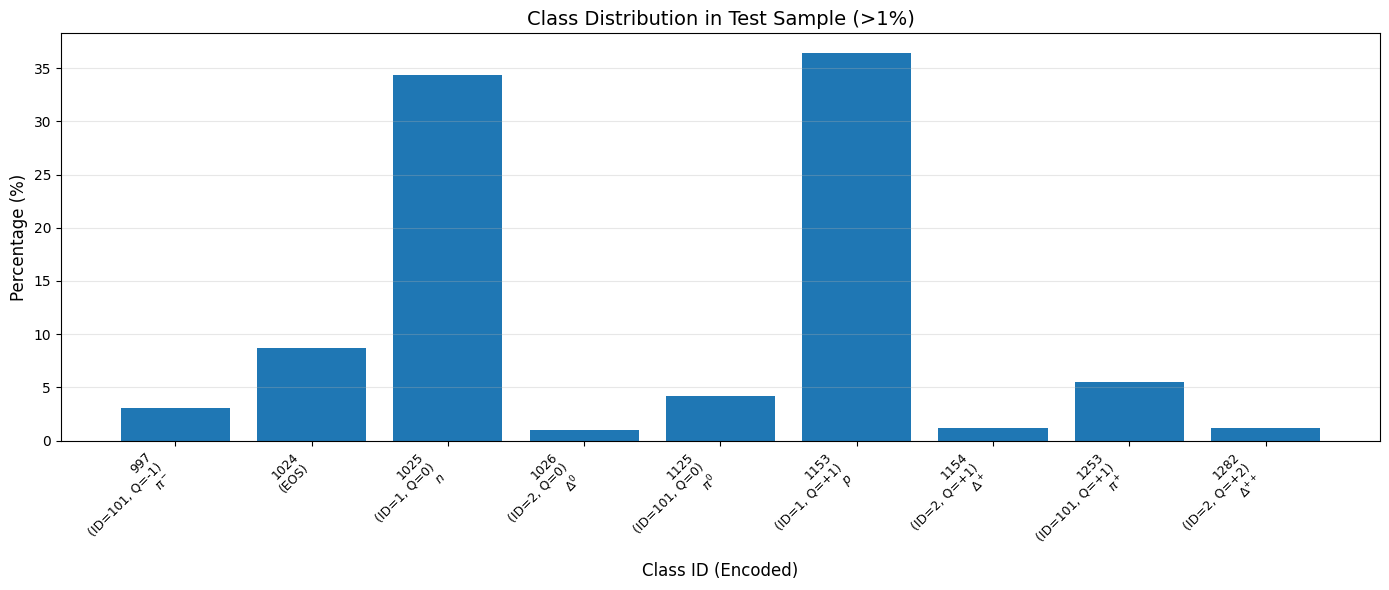


Total classes with >1%: 9
Total classes: 115


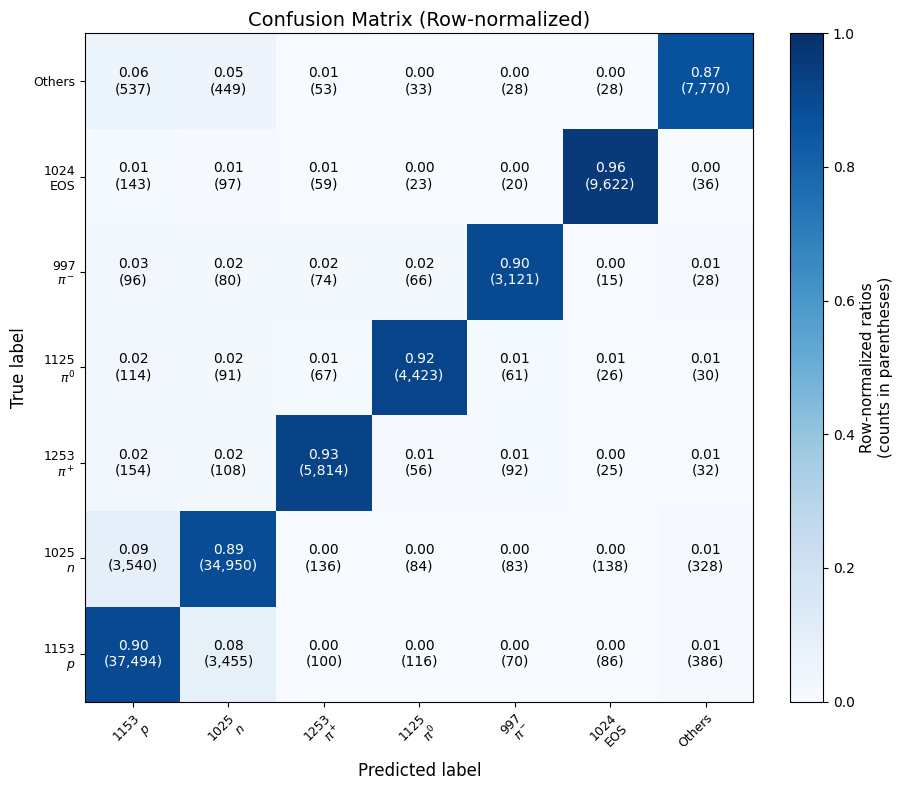


✓ Confusion matrix displayed
  Main classes: ['$p$', '$n$', '$\\pi^+$', '$\\pi^0$', '$\\pi^-$', 'EOS']
  Total predictions: 114,437


In [93]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Flatten targets (excluding PAD tokens)
flat_targets = all_true_types[all_masks].cpu().numpy().flatten()

# Count occurrences
unique, counts = np.unique(flat_targets, return_counts=True)
total = counts.sum()
percentages = counts / total

# Filter for classes exceeding 1%
mask_threshold = percentages > 0.01
filtered_classes = unique[mask_threshold]
filtered_percentages = percentages[mask_threshold]

# Plot class distribution with GiBUU_ID and charge labels
from gibuu_transformer.data_processing import decode_id

# Dictionary mapping encoded IDs to particle names (LaTeX format)
PARTICLE_NAME_DICT = {
    1153: r"$p$",           # proton
    1025: r"$n$",           # neutron
    1253: r"$\pi^+$",       # pi+
    1125: r"$\pi^0$",       # pi0
    997: r"$\pi^-$",        # pi-
    1282: r"$\Delta^{++}$", # Delta++
    1154: r"$\Delta^+$",    # Delta+
    1026: r"$\Delta^0$",    # Delta0
    898: r"$\Delta^-$",     # Delta-
    1126: r"$\eta$",        # η (102, 0)
    1129: r"$\omega$",      # ω (105, 0)
    1255: r"$\rho^+$",      # ρ^+ (103, 1)
    1262: r"$K^+$",         # K^+ (110, 1)
    1127: r"$\rho^0$",      # ρ^0 (103, 0)
    1056: r"$\Lambda$",     # Λ (32, 0)
    999: r"$\rho^-$",       # ρ^- (103, -1)
    1134: r"$K^0$",         # K^0 (110, 0)
    1155: r"$P_{11}(1440)$", # P11(1440) (3, 1)
    1159: r"$D_{13}(1520)$", # D13(1520) (7, 1)
    1027: r"$P_{11}(1440)$", # P11(1440) (3, 0)
}

# Create labels with encoded ID, decoded GiBUU_ID/charge, and particle name
def create_class_label(encoded_id):
    """Create label with encoded ID, decoded GiBUU_ID/charge, and particle name."""
    encoded_id_int = int(encoded_id)
    
    if encoded_id_int == EOS_STEP_TOKEN:
        return f"{encoded_id_int}\n(EOS)"
    elif encoded_id_int == PAD_TOKEN:
        return f"{encoded_id_int}\n(PAD)"
    elif encoded_id_int == START_TOKEN:
        return f"{encoded_id_int}\n(START)"
    else:
        try:
            gibuu_id, charge, is_real = decode_id(encoded_id_int)
            charge_str = f"+{charge}" if charge > 0 else str(charge) if charge < 0 else "0"
            particle_name = PARTICLE_NAME_DICT.get(encoded_id_int, "Unknown")
            return f"{encoded_id_int}\n(ID={gibuu_id}, Q={charge_str})\n{particle_name}"
        except:
            particle_name = PARTICLE_NAME_DICT.get(encoded_id_int, "Unknown")
            return f"{encoded_id_int}\n{particle_name}"

class_labels = [create_class_label(c) for c in filtered_classes]

plt.figure(figsize=(14, 6))
plt.bar(range(len(filtered_classes)), filtered_percentages * 100)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xlabel("Class ID (Encoded)", fontsize=12)
plt.title("Class Distribution in Test Sample (>1%)", fontsize=14)
plt.xticks(range(len(filtered_classes)), class_labels, rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal classes with >1%: {len(filtered_classes)}")
print(f"Total classes: {len(unique)}")

# ========== CONFUSION MATRIX ==========
# Use common particle types from the dictionary
# Start with most common particles
main_encoded_ids = [1153, 1025, 1253, 1125, 997]  # p, n, pi+, pi0, pi-
main_names = [PARTICLE_NAME_DICT.get(eid, f"Class {eid}") for eid in main_encoded_ids]

# Add EOS token
main_encoded_ids.append(EOS_STEP_TOKEN)
main_names.append("EOS")

# If main classes are not in the data, use top classes from distribution
main_encoded_ids_in_data = [eid for eid in main_encoded_ids if eid in unique]
if len(main_encoded_ids_in_data) < 3:
    # Use top classes from distribution
    top_indices = np.argsort(counts)[-6:][::-1]  # Top 6
    main_encoded_ids = unique[top_indices].tolist()
    main_names = [PARTICLE_NAME_DICT.get(int(eid), f"Class {int(eid)}") for eid in main_encoded_ids]

others_label = 9999  # Use a value not in your classes

# Flatten predictions and targets, mask out PAD tokens
y_true = all_true_types[all_masks].cpu().numpy().flatten()
y_pred = all_predicted_types[all_masks].cpu().numpy().flatten()

# Map to main classes or "others"
def map_to_main_or_others(arr):
    return np.array([x if x in main_encoded_ids else others_label for x in arr])

y_true_mapped = map_to_main_or_others(y_true)
y_pred_mapped = map_to_main_or_others(y_pred)

# Prepare labels for confusion matrix
labels = main_encoded_ids + [others_label]
label_names = main_names + ['Others']

# Compute confusion matrix (absolute counts)
cm_counts = confusion_matrix(y_true_mapped, y_pred_mapped, labels=labels)

# Normalize along each true axis (row)
cm_ratios = cm_counts.astype(float)
row_sums = cm_ratios.sum(axis=1, keepdims=True)
cm_ratios = np.divide(cm_ratios, row_sums, where=row_sums != 0)  # Avoid division by zero

# Plot heatmap using ratios as colors
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_ratios, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)

# Add text: ratio + absolute count
for i in range(cm_counts.shape[0]):
    for j in range(cm_counts.shape[1]):
        ratio = cm_ratios[i, j]
        count = cm_counts[i, j]
        text_color = "white" if ratio > 0.5 else "black"
        ax.text(j, i, f"{ratio:.2f}\n({count:,})",
                ha="center", va="center", color=text_color, fontsize=10)

# Create labels with embedded ID and particle name (no ID and Q)
def create_confusion_label(encoded_id, name):
    """Create label with embedded ID and particle name."""
    encoded_id_int = int(encoded_id)
    
    if encoded_id_int == EOS_STEP_TOKEN:
        return f"{encoded_id_int}\n{name}"
    elif encoded_id_int == others_label:
        return f"{name}"
    else:
        # Use particle name from dictionary if available, otherwise use provided name
        particle_name = PARTICLE_NAME_DICT.get(encoded_id_int, name)
        return f"{encoded_id_int}\n{particle_name}"

confusion_labels = [create_confusion_label(lid, name) for lid, name in zip(labels, label_names)]

# Set ticks and labels
ax.set_xticks(np.arange(len(label_names)))
ax.set_yticks(np.arange(len(label_names)))
ax.set_xticklabels(confusion_labels, fontsize=9)
ax.set_yticklabels(confusion_labels, fontsize=9)
ax.set_ylabel("True label", fontsize=12)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_title("Confusion Matrix (Row-normalized)", fontsize=14)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.invert_yaxis()  # Origin at lower left

# Add colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Row-normalized ratios\n(counts in parentheses)", fontsize=11)

plt.tight_layout()
plt.show()

print(f"\n✓ Confusion matrix displayed")
print(f"  Main classes: {label_names[:-1]}")
print(f"  Total predictions: {len(y_true):,}")


2D FEATURE DISTRIBUTION PLOTS (Predicted vs True)

Note: Only showing particles with matched IDs (predicted type == true type)
      Excluding EOS and PAD tokens



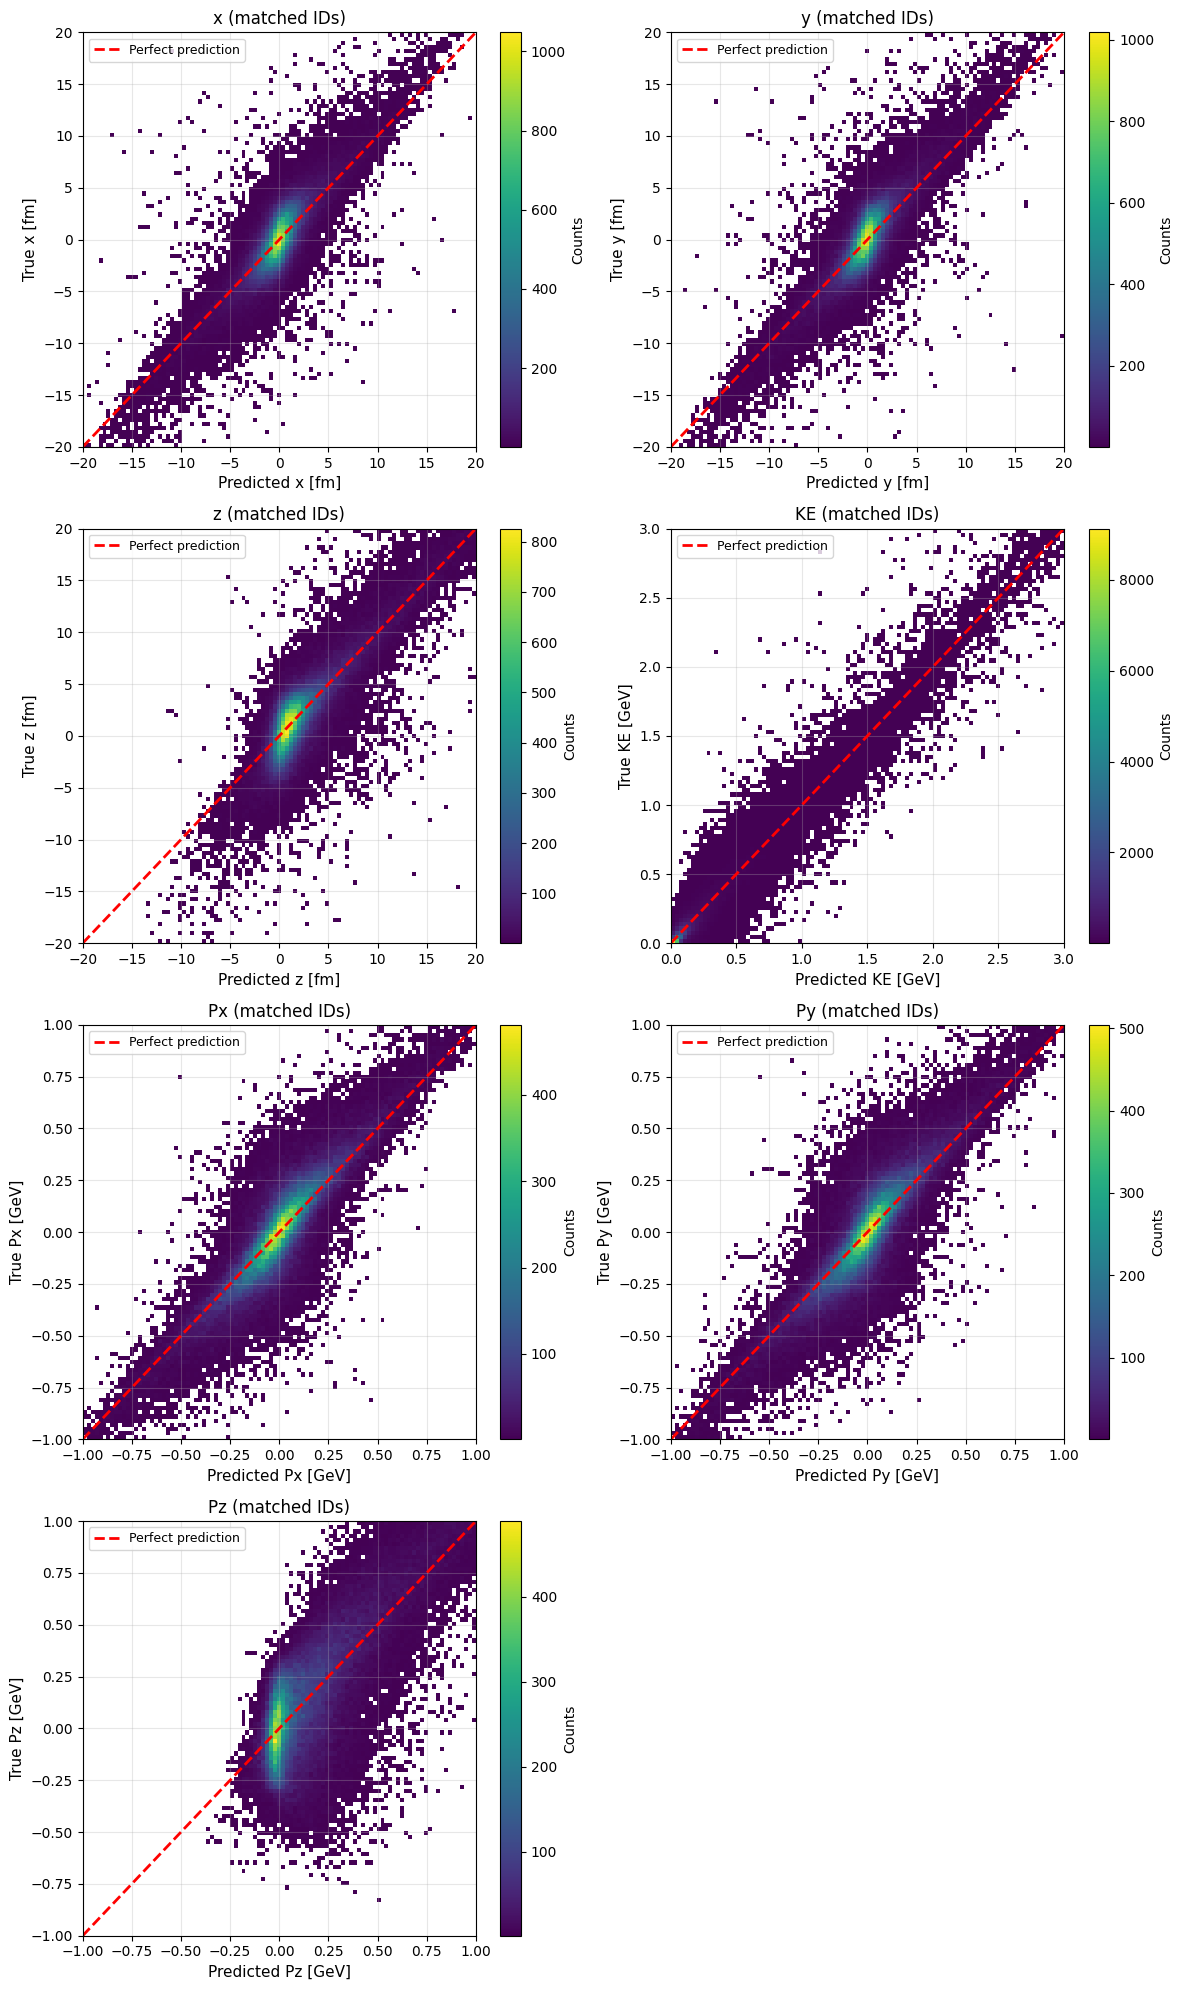


FEATURE STATISTICS (matched IDs only)
Feature  MAE          RMSE         MedAE        N           
--------------------------------------------------------------------------------
x        1.490600     2.087729     1.160887     92,938      
y        1.474516     2.081997     1.149426     92,938      
z        1.690248     2.450765     1.255552     92,938      
KE       0.062234     0.117888     0.030187     92,938      
Px       0.087584     0.124859     0.061819     92,938      
Py       0.091129     0.130967     0.063794     92,938      
Pz       0.152680     0.206875     0.120261     92,938      

✓ All feature distributions plotted


In [92]:
def plot_2d_feature_distribution_subplot(
    ax, all_feats_pred, all_feats_target, all_preds, all_targets, all_masks,
    feature_index, feature_name, matched=False, particle_id=None, bins=None, 
    vmin=None, vmax=None, xlabel="Predicted", ylabel="True", title="2D Feature Distribution"
):
    """
    Draws a 2D histogram of a feature: predicted vs. true on a given axis.
    
    Parameters:
    -----------
    ax: matplotlib axis to plot on
    all_feats_pred: tensor/array, shape [N, seq_len, n_feat] - denormalized
    all_feats_target: tensor/array, shape [N, seq_len, n_feat] - denormalized
    all_preds: tensor/array, shape [N, seq_len]
    all_targets: tensor/array, shape [N, seq_len]
    all_masks: tensor/array, shape [N, seq_len] - True for valid tokens
    feature_index: int, which feature to plot (0=x, 1=y, 2=z, 3=KE, 4=Px, 5=Py, 6=Pz)
    feature_name: str, name of the feature for labels
    matched: bool, if True, only plot where predicted ID == true ID
    particle_id: int, list or None, if set, only plot for the provided IDs
    bins: list, bin edges for the histogram
    vmin, vmax: for color scale
    xlabel, ylabel, title: plot labels
    """
    # Flatten everything
    pred_ids = all_preds.flatten()
    true_ids = all_targets.flatten()
    pred_feat = all_feats_pred[..., feature_index].flatten()
    true_feat = all_feats_target[..., feature_index].flatten()
    valid_mask = all_masks.flatten()
    
    # Mask for non-particle tokens (exclude PAD and EOS for features)
    mask = valid_mask & (true_ids != PAD_TOKEN) & (true_ids != EOS_STEP_TOKEN)
    if matched:
        mask = mask & (pred_ids == true_ids)
    if particle_id is not None:
        if type(particle_id) is int:
            particle_id = [particle_id]
        mask = mask & np.isin(true_ids, particle_id)
    
    # Apply mask
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()
    x = pred_feat[mask].cpu().numpy() if isinstance(pred_feat, torch.Tensor) else pred_feat[mask]
    y = true_feat[mask].cpu().numpy() if isinstance(true_feat, torch.Tensor) else true_feat[mask]

    # Set the same range for both axes
    if bins is None:
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        bins = np.linspace(min_val, max_val, 101)
    xmin = bins[0]
    xmax = bins[-1]

    # Set up colormap with white for empty bins
    cmap = plt.get_cmap('viridis').copy()
    cmap.set_bad('white')
    
    h = ax.hist2d(x, y, bins=bins, cmap=cmap, cmin=1, vmin=vmin, vmax=vmax)
    ax.plot([xmin, xmax], [xmin, xmax], "r--", linewidth=2, label="Perfect prediction")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(xmin, xmax)
    
    # Add title with additional info
    title_suffix = ""
    if matched:
        title_suffix += " (matched IDs)"
    if particle_id is not None:
        title_suffix += f" (ID={particle_id})"
    ax.set_title(title + title_suffix, fontsize=12)
    plt.colorbar(h[3], ax=ax, label="Counts")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # Return statistics
    errors = np.abs(x - y)
    return {
        'mae': errors.mean(),
        'rmse': np.sqrt(np.mean((x - y)**2)),
        'medae': np.median(errors),
        'n_points': len(x)
    }

# Use denormalized features from evaluation
# Feature names and indices - ordered as: x, y, z, KE, Px, Py, Pz
feature_info = [
    (0, 'x', 'x [fm]', np.linspace(-20, 20, 100)),
    (1, 'y', 'y [fm]', np.linspace(-20, 20, 100)),
    (2, 'z', 'z [fm]', np.linspace(-20, 20, 100)),
    (3, 'KE', 'KE [GeV]', np.linspace(0, 3, 100)),
    (4, 'Px', 'Px [GeV]', np.linspace(-1, 1, 100)),
    (5, 'Py', 'Py [GeV]', np.linspace(-1, 1, 100)),
    (6, 'Pz', 'Pz [GeV]', np.linspace(-1, 1, 100)),
]

print(f"{'='*80}")
print("2D FEATURE DISTRIBUTION PLOTS (Predicted vs True)")
print(f"{'='*80}")
print("\nNote: Only showing particles with matched IDs (predicted type == true type)")
print("      Excluding EOS and PAD tokens\n")

# Create subplots: 2 per row, 4 rows total
# Layout: x, y | z, KE | Px, Py | Pz
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
axes = axes.flatten()

# Plot all features in order
stats_dict = {}
for idx, (feat_idx, feat_short, feat_name, default_bins) in enumerate(feature_info):
    # Determine bins based on feature
    if feat_short in ['x', 'y', 'z']:
        bins = np.linspace(-20, 20, 100)
    elif feat_short == 'KE':
        bins = np.linspace(0, 3, 100)
    else:  # Px, Py, Pz
        bins = np.linspace(-1, 1, 100)
    
    stats = plot_2d_feature_distribution_subplot(
        axes[idx], predicted_feats_denorm, true_feats_denorm, 
        all_predicted_types, all_true_types, all_masks,
        feature_index=feat_idx, 
        feature_name=feat_short,
        matched=True,  # Only plot where predicted ID matches true ID
        particle_id=None,  # All particle types
        bins=bins,
        xlabel=f"Predicted {feat_name}",
        ylabel=f"True {feat_name}",
        title=f"{feat_short}"
    )
    stats_dict[feat_short] = stats

# Hide the last subplot (8th position, since we only have 7 features)
axes[7].axis('off')

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n{'='*80}")
print("FEATURE STATISTICS (matched IDs only)")
print(f"{'='*80}")
print(f"{'Feature':<8} {'MAE':<12} {'RMSE':<12} {'MedAE':<12} {'N':<12}")
print(f"{'-'*80}")
for feat_short in ['x', 'y', 'z', 'KE', 'Px', 'Py', 'Pz']:
    stats = stats_dict[feat_short]
    print(f"{feat_short:<8} {stats['mae']:<12.6f} {stats['rmse']:<12.6f} {stats['medae']:<12.6f} {stats['n_points']:<12,}")

print(f"\n{'='*80}")
print("✓ All feature distributions plotted")


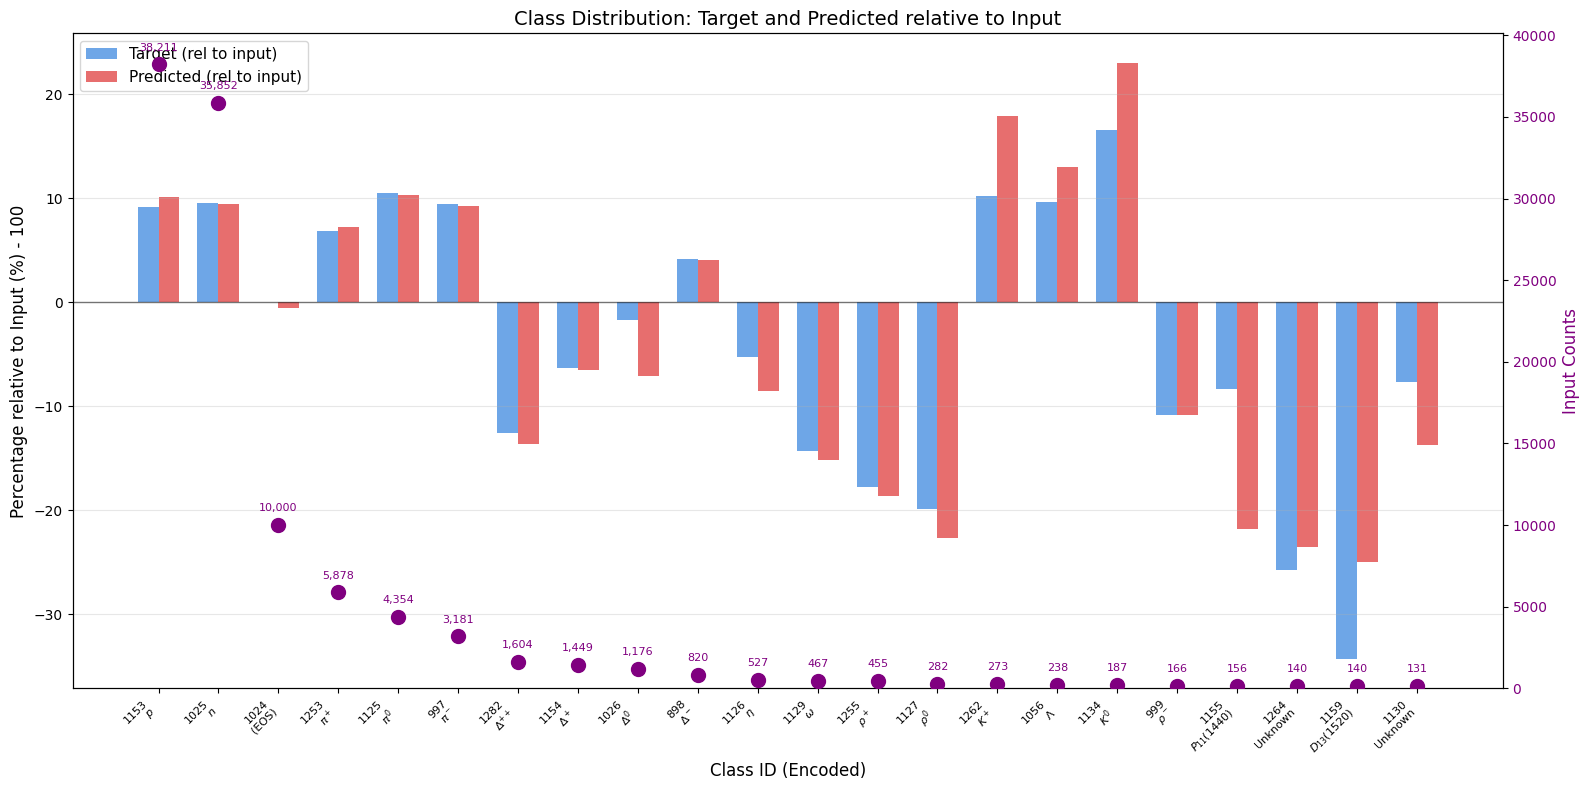


SUMMARY
  Total input particles: 106,928
  Total target particles: 114,437
  Total predicted particles: 114,437
  Classes shown: 22 (out of 121 total)
  Filter threshold: >0.1% of total input

  Top 5 classes by input count:
    Class 1153: Input=38,211, Target=109.1%, Predicted=110.1%
    Class 1025: Input=35,852, Target=109.5%, Predicted=109.4%
    Class 1024: Input=10,000, Target=100.0%, Predicted=99.4%
    Class 1253: Input=5,878, Target=106.9%, Predicted=107.2%
    Class 1125: Input=4,354, Target=110.5%, Predicted=110.3%


In [107]:
# Get input types from test batches
all_input_types = []
all_input_masks = []

model_loaded.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        input_ids = batch['input_encoded_ids'].cpu()
        input_mask = ~batch['input_padding_mask'].cpu()
        all_input_types.append(input_ids)
        all_input_masks.append(input_mask)

# Concatenate and flatten
all_input_types_flat = torch.cat([t[m] for t, m in zip(all_input_types, all_input_masks)], dim=0).numpy()
all_target_types_flat = all_true_types[all_masks].cpu().numpy().flatten()
all_predicted_types_flat = all_predicted_types[all_masks].cpu().numpy().flatten()

# Get unique classes from all three
all_classes = np.unique(np.concatenate([all_input_types_flat, all_target_types_flat, all_predicted_types_flat]))

# Count occurrences
input_counts = np.array([np.sum(all_input_types_flat == c) for c in all_classes])
target_counts = np.array([np.sum(all_target_types_flat == c) for c in all_classes])
predicted_counts = np.array([np.sum(all_predicted_types_flat == c) for c in all_classes])

# Calculate target and predicted as percentages relative to input counts for each class
# For each class: (target_count / input_count) * 100 and (predicted_count / input_count) * 100
target_percentages_rel = np.zeros_like(target_counts, dtype=float)
predicted_percentages_rel = np.zeros_like(predicted_counts, dtype=float)

for i, input_count in enumerate(input_counts):
    if input_count > 0:
        target_percentages_rel[i] = (target_counts[i] / input_count) * 100
        predicted_percentages_rel[i] = (predicted_counts[i] / input_count) * 100
    else:
        target_percentages_rel[i] = 0.0
        predicted_percentages_rel[i] = 0.0

# Filter for classes with significant input counts (e.g., >0.1% of total input)
input_total = input_counts.sum()
min_percentage = 0.1
significant_mask = (input_counts / input_total * 100) > min_percentage if input_total > 0 else input_counts > 0
filtered_classes = all_classes[significant_mask]
filtered_target_pct = target_percentages_rel[significant_mask]
filtered_predicted_pct = predicted_percentages_rel[significant_mask]
filtered_input_counts = input_counts[significant_mask]

# Sort by descending input counts
sort_indices = np.argsort(filtered_input_counts)[::-1]
filtered_classes = filtered_classes[sort_indices]
filtered_target_pct = filtered_target_pct[sort_indices]
filtered_predicted_pct = filtered_predicted_pct[sort_indices]
filtered_input_counts = filtered_input_counts[sort_indices]

# Create labels without (ID and Q) - just encoded ID and particle name
def create_simple_class_label(encoded_id):
    """Create label with encoded ID and particle name only."""
    encoded_id_int = int(encoded_id)
    
    if encoded_id_int == EOS_STEP_TOKEN:
        return f"{encoded_id_int}\n(EOS)"
    elif encoded_id_int == PAD_TOKEN:
        return f"{encoded_id_int}\n(PAD)"
    elif encoded_id_int == START_TOKEN:
        return f"{encoded_id_int}\n(START)"
    else:
        particle_name = PARTICLE_NAME_DICT.get(encoded_id_int, "Unknown")
        return f"{encoded_id_int}\n{particle_name}"

class_labels = [create_simple_class_label(c) for c in filtered_classes]

# Plot
fig, ax1 = plt.subplots(figsize=(16, 8))

x_pos = np.arange(len(filtered_classes))
width = 0.35

# Subtract 1 from percentages (so 100% becomes 0%, 109% becomes 9%, etc.)
filtered_target_pct_centered = filtered_target_pct - 100
filtered_predicted_pct_centered = filtered_predicted_pct - 100

# Left axis: percentages relative to input (centered at 0)
bars2 = ax1.bar(x_pos - width/2, filtered_target_pct_centered, width, label='Target (rel to input)', alpha=0.8, color='#4A90E2')  # dim blue
bars3 = ax1.bar(x_pos + width/2, filtered_predicted_pct_centered, width, label='Predicted (rel to input)', alpha=0.8, color='#E24A4A')  # dim red

# Add horizontal line at 0
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

ax1.set_xlabel('Class ID (Encoded)', fontsize=12)
ax1.set_ylabel('Percentage relative to Input (%) - 100', fontsize=12, color='black')
ax1.set_title('Class Distribution: Target and Predicted relative to Input', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(class_labels, rotation=45, ha='right', fontsize=8)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Right axis: input counts (markers only, no line)
ax2 = ax1.twinx()
markers = ax2.scatter(x_pos, filtered_input_counts, color='purple', s=100, marker='o', zorder=5, label='Input Counts')
ax2.set_ylabel('Input Counts', fontsize=12, color='purple')
ax2.set_ylim(0, None)  # Start from 0
ax2.tick_params(axis='y', labelcolor='purple')

# Add count annotations on the markers
for i, (x, count) in enumerate(zip(x_pos, filtered_input_counts)):
    if count > 0:
        ax2.annotate(f'{count:,}', (x, count), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=8, color='purple')

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print(f"  Total input particles: {input_total:,}")
print(f"  Total target particles: {target_counts.sum():,}")
print(f"  Total predicted particles: {predicted_counts.sum():,}")
print(f"  Classes shown: {len(filtered_classes)} (out of {len(all_classes)} total)")
print(f"  Filter threshold: >{min_percentage}% of total input")
print(f"\n  Top 5 classes by input count:")
for i in range(min(5, len(filtered_classes))):
    c = filtered_classes[i]
    inp_cnt = filtered_input_counts[i]
    targ_pct = filtered_target_pct[i]
    pred_pct = filtered_predicted_pct[i]
    print(f"    Class {int(c)}: Input={inp_cnt:,}, Target={targ_pct:.1f}%, Predicted={pred_pct:.1f}%")


FEATURE DISTRIBUTIONS: Target vs Predicted (all particles)

Debug info:
  all_true_types shape: torch.Size([10000, 48])
  all_predicted_types shape: torch.Size([10000, 48])
  predicted_feats_denorm shape: torch.Size([10000, 48, 7])
  true_feats_denorm shape: torch.Size([10000, 48, 7])
  true_ids_flat length: 480,000
  feature_mask length: 480,000
  Valid positions (non-PAD, non-EOS): 104,437


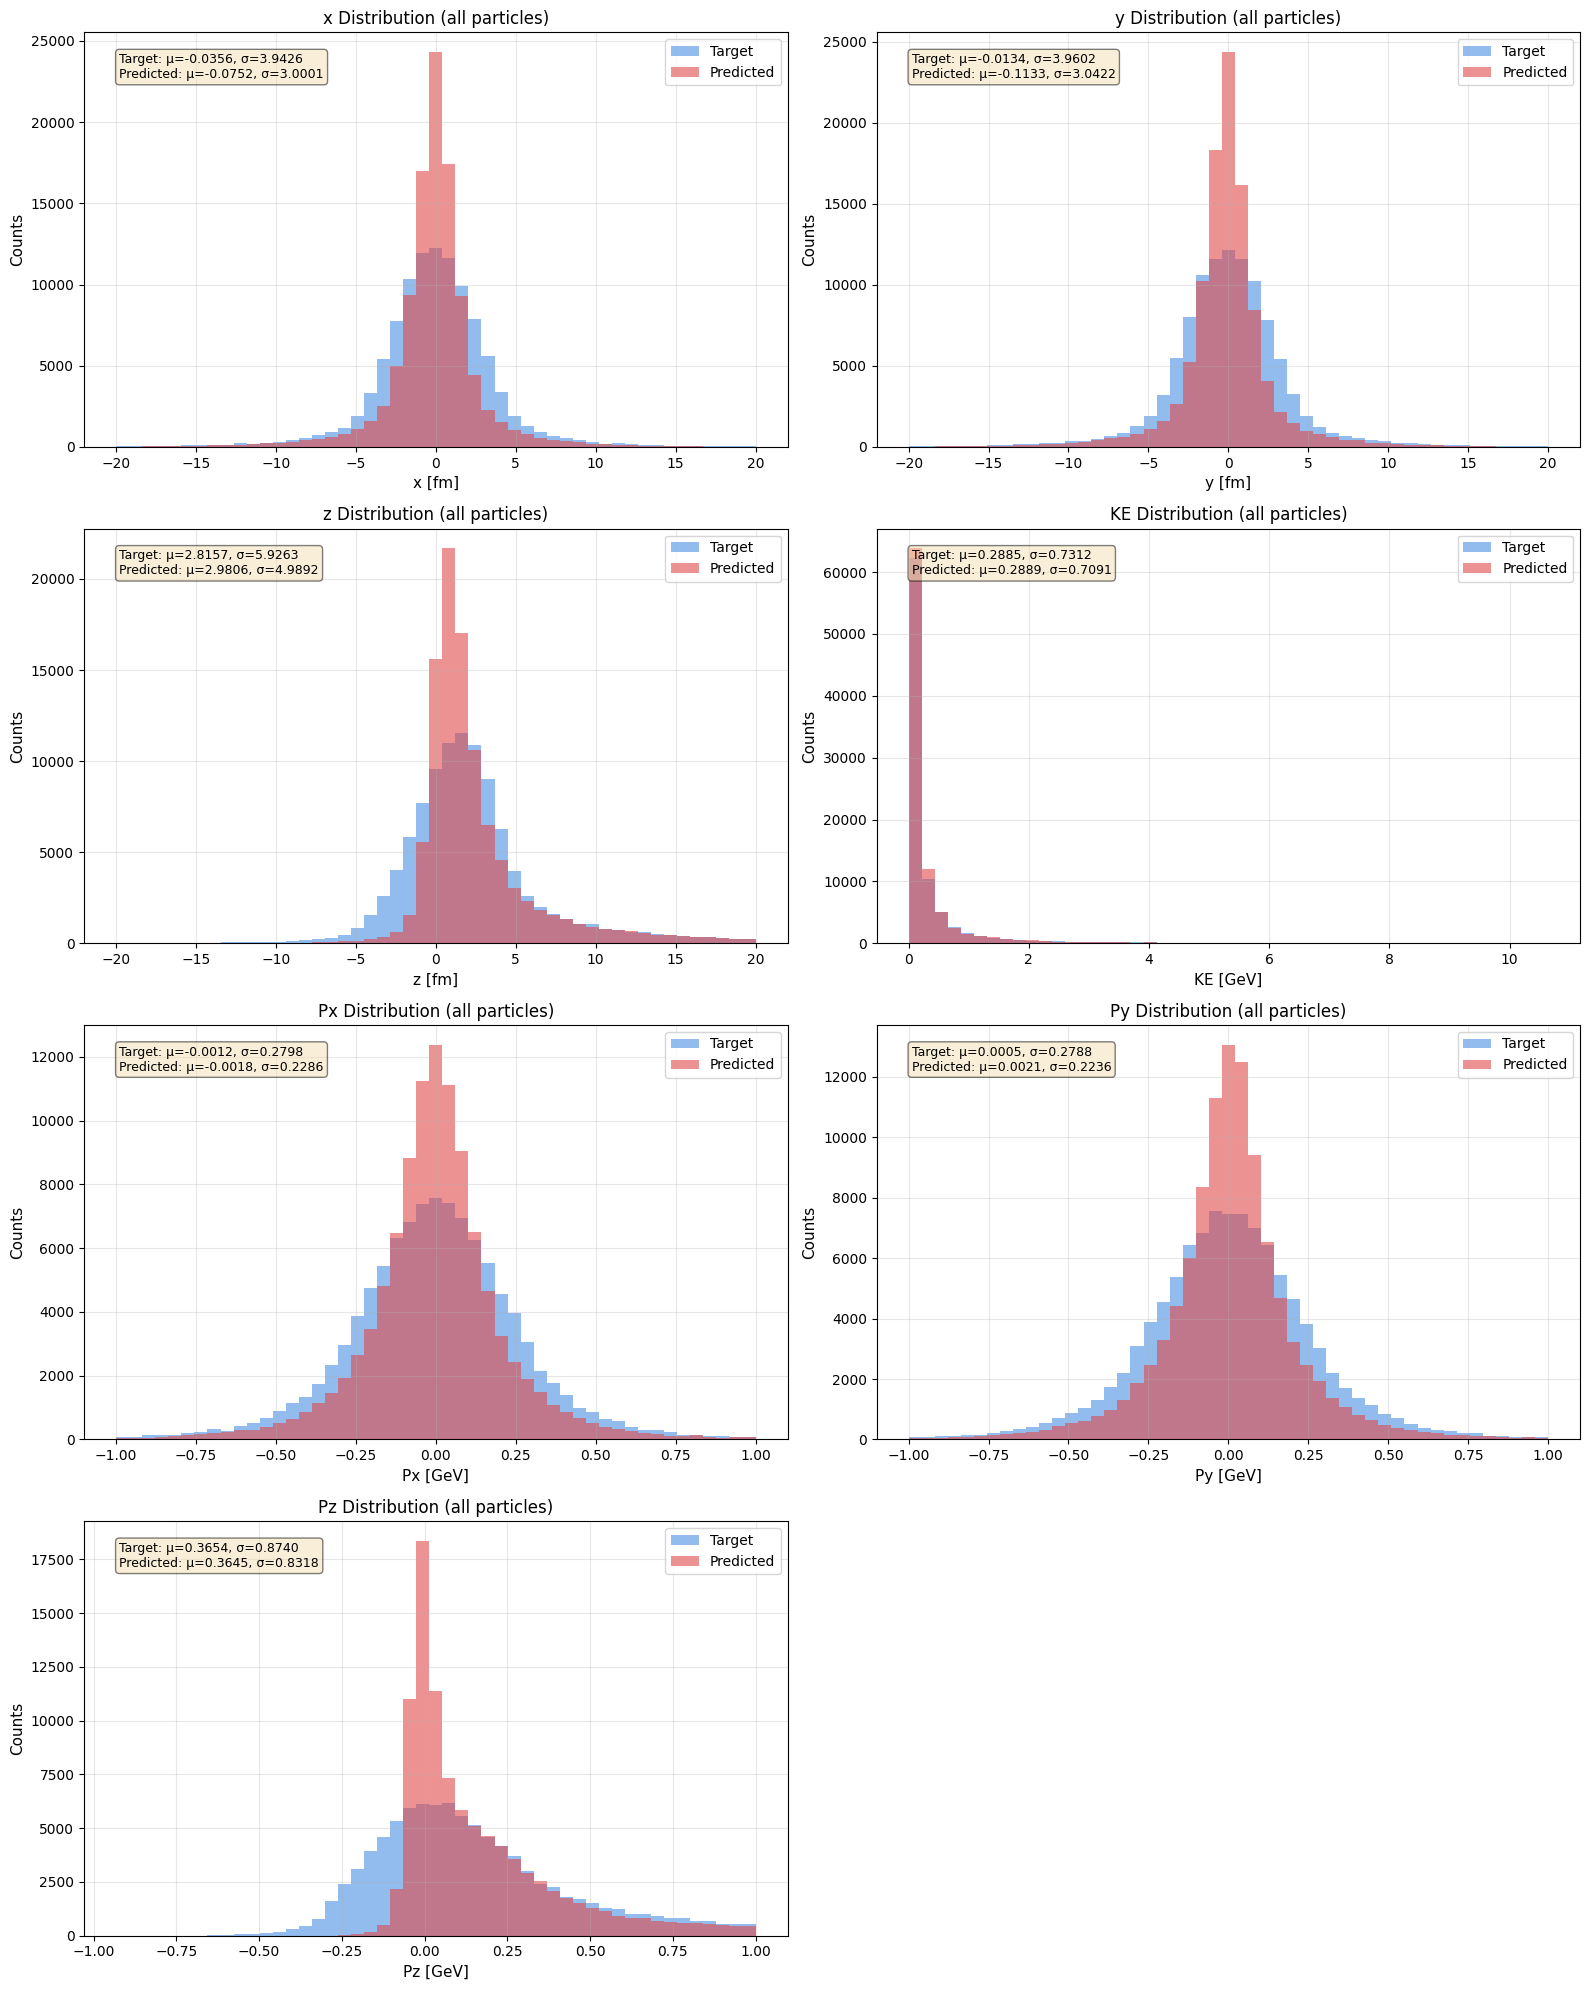


FEATURE STATISTICS
Feature  Target Mean     Target Std      Pred Mean       Pred Std        N         
--------------------------------------------------------------------------------
x        -0.035629       3.942616        -0.075235       3.000064        104,437   
y        -0.013419       3.960199        -0.113252       3.042205        104,437   
z        2.815729        5.926331        2.980644        4.989210        104,437   
KE       0.288506        0.731236        0.288885        0.709070        104,437   
Px       -0.001222       0.279774        -0.001846       0.228609        104,437   
Py       0.000494        0.278808        0.002129        0.223575        104,437   
Pz       0.365359        0.873952        0.364526        0.831793        104,437   

✓ Feature distributions plotted
  Showing all particles (excluding EOS and PAD)


In [116]:
# Configuration: filter by embedded ID(s) if desired
# Set to None to show all particles, or provide a single ID or list of IDs
FILTER_BY_IDS = None  # Example: 1153 for proton, or [1153, 1025] for proton and neutron

# Feature names and indices
feature_info = [
    (0, 'x', 'x [fm]'),
    (1, 'y', 'y [fm]'),
    (2, 'z', 'z [fm]'),
    (3, 'KE', 'KE [GeV]'),
    (4, 'Px', 'Px [GeV]'),
    (5, 'Py', 'Py [GeV]'),
    (6, 'Pz', 'Pz [GeV]'),
]

# Flatten all data
pred_ids_flat = all_predicted_types.flatten()
true_ids_flat = all_true_types.flatten()
valid_mask_flat = all_masks.flatten()

# Convert to numpy for easier manipulation
if isinstance(pred_ids_flat, torch.Tensor):
    pred_ids_flat = pred_ids_flat.cpu().numpy()
if isinstance(true_ids_flat, torch.Tensor):
    true_ids_flat = true_ids_flat.cpu().numpy()
if isinstance(valid_mask_flat, torch.Tensor):
    valid_mask_flat = valid_mask_flat.cpu().numpy()

# Create mask: exclude PAD always, exclude EOS only if not explicitly filtering
if FILTER_BY_IDS is not None:
    if isinstance(FILTER_BY_IDS, (int, np.integer)):
        filter_ids = [int(FILTER_BY_IDS)]
    else:
        filter_ids = [int(fid) for fid in FILTER_BY_IDS]
    
    # When filtering, only exclude PAD (allow EOS if requested)
    feature_mask = valid_mask_flat & (true_ids_flat != PAD_TOKEN)
    # Apply ID filter
    feature_mask = feature_mask & np.isin(true_ids_flat, filter_ids)
    filter_str = f" (filtered: IDs={filter_ids})"
else:
    # Default: exclude both PAD and EOS
    feature_mask = valid_mask_flat & (true_ids_flat != PAD_TOKEN) & (true_ids_flat != EOS_STEP_TOKEN)
    filter_str = " (all particles)"

print(f"{'='*80}")
print(f"FEATURE DISTRIBUTIONS: Target vs Predicted{filter_str}")
print(f"{'='*80}")

# Debug: Check mask application and shapes
print(f"\nDebug info:")
print(f"  all_true_types shape: {all_true_types.shape}")
print(f"  all_predicted_types shape: {all_predicted_types.shape}")
print(f"  predicted_feats_denorm shape: {predicted_feats_denorm.shape}")
print(f"  true_feats_denorm shape: {true_feats_denorm.shape}")
print(f"  true_ids_flat length: {len(true_ids_flat):,}")
print(f"  feature_mask length: {len(feature_mask):,}")
print(f"  Valid positions (non-PAD, non-EOS): {feature_mask.sum():,}")
if FILTER_BY_IDS is not None:
    print(f"  Filter IDs: {filter_ids}")
    filtered_count = (np.isin(true_ids_flat, filter_ids) & feature_mask).sum()
    print(f"  Positions matching filter: {filtered_count:,}")

# Create subplots: 2 per row, 4 rows total
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, (feat_idx, feat_short, feat_name) in enumerate(feature_info):
    ax = axes[idx]
    
    # Get feature values
    pred_feat_flat = predicted_feats_denorm[..., feat_idx].flatten()
    true_feat_flat = true_feats_denorm[..., feat_idx].flatten()
    
    # Convert to numpy if needed
    if isinstance(pred_feat_flat, torch.Tensor):
        pred_feat_flat = pred_feat_flat.cpu().numpy()
    if isinstance(true_feat_flat, torch.Tensor):
        true_feat_flat = true_feat_flat.cpu().numpy()
    
    # Apply mask (ensure same length)
    if len(pred_feat_flat) != len(feature_mask) or len(true_feat_flat) != len(feature_mask):
        print(f"  WARNING: Length mismatch for {feat_short}: pred={len(pred_feat_flat)}, true={len(true_feat_flat)}, mask={len(feature_mask)}")
        # Truncate to minimum length
        min_len = min(len(pred_feat_flat), len(true_feat_flat), len(feature_mask))
        pred_feat_flat = pred_feat_flat[:min_len]
        true_feat_flat = true_feat_flat[:min_len]
        feature_mask_local = feature_mask[:min_len]
    else:
        feature_mask_local = feature_mask
    
    pred_feat_masked = pred_feat_flat[feature_mask_local]
    true_feat_masked = true_feat_flat[feature_mask_local]
    
    # Determine bins based on combined data range (same binning for target and predicted)
    combined_data = np.concatenate([true_feat_masked, pred_feat_masked])
    if len(combined_data) > 0:
        data_min = np.min(combined_data)
        data_max = np.max(combined_data)
        
        # Use appropriate bin range based on feature type
        if feat_short in ['x', 'y', 'z']:
            bin_min = max(-20, data_min - 1)
            bin_max = min(20, data_max + 1)
            n_bins = 50
        elif feat_short == 'KE':
            bin_min = 0
            bin_max = max(3, data_max + 0.1)
            n_bins = 50
        else:  # Px, Py, Pz
            bin_min = max(-1, data_min - 0.1)
            bin_max = min(1, data_max + 0.1)
            n_bins = 50
        
        bins = np.linspace(bin_min, bin_max, n_bins)
    else:
        # Fallback if no data
        if feat_short in ['x', 'y', 'z']:
            bins = np.linspace(-20, 20, 50)
        elif feat_short == 'KE':
            bins = np.linspace(0, 3, 50)
        else:
            bins = np.linspace(-1, 1, 50)
    
    # Plot histograms with counts (not density), using same bins, no edge color
    counts_true, bins_true, patches_true = ax.hist(true_feat_masked, bins=bins, alpha=0.6, label='Target', color='#4A90E2', edgecolor='none')  # dim blue
    counts_pred, bins_pred, patches_pred = ax.hist(pred_feat_masked, bins=bins, alpha=0.6, label='Predicted', color='#E24A4A', edgecolor='none')  # dim red
    
    ax.set_xlabel(feat_name, fontsize=11)
    ax.set_ylabel('Counts', fontsize=11)
    ax.set_title(f'{feat_short} Distribution{filter_str}', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    
    # Add statistics text
    true_mean = np.mean(true_feat_masked)
    true_std = np.std(true_feat_masked)
    pred_mean = np.mean(pred_feat_masked)
    pred_std = np.std(pred_feat_masked)
    
    stats_text = f'Target: μ={true_mean:.4f}, σ={true_std:.4f}\n'
    stats_text += f'Predicted: μ={pred_mean:.4f}, σ={pred_std:.4f}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=9, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide the last subplot (8th position)
axes[7].axis('off')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n{'='*80}")
print("FEATURE STATISTICS")
print(f"{'='*80}")
print(f"{'Feature':<8} {'Target Mean':<15} {'Target Std':<15} {'Pred Mean':<15} {'Pred Std':<15} {'N':<10}")
print(f"{'-'*80}")

for feat_idx, feat_short, feat_name in feature_info:
    pred_feat_flat = predicted_feats_denorm[..., feat_idx].flatten()
    true_feat_flat = true_feats_denorm[..., feat_idx].flatten()
    
    if isinstance(pred_feat_flat, torch.Tensor):
        pred_feat_flat = pred_feat_flat.cpu().numpy()
    if isinstance(true_feat_flat, torch.Tensor):
        true_feat_flat = true_feat_flat.cpu().numpy()
    
    # Apply mask (ensure same length)
    if len(pred_feat_flat) != len(feature_mask) or len(true_feat_flat) != len(feature_mask):
        min_len = min(len(pred_feat_flat), len(true_feat_flat), len(feature_mask))
        pred_feat_flat = pred_feat_flat[:min_len]
        true_feat_flat = true_feat_flat[:min_len]
        feature_mask_local = feature_mask[:min_len]
    else:
        feature_mask_local = feature_mask
    
    pred_feat_masked = pred_feat_flat[feature_mask_local]
    true_feat_masked = true_feat_flat[feature_mask_local]
    
    true_mean = np.mean(true_feat_masked)
    true_std = np.std(true_feat_masked)
    pred_mean = np.mean(pred_feat_masked)
    pred_std = np.std(pred_feat_masked)
    
    print(f"{feat_short:<8} {true_mean:<15.6f} {true_std:<15.6f} {pred_mean:<15.6f} {pred_std:<15.6f} {len(true_feat_masked):<10,}")

print(f"\n{'='*80}")
print("✓ Feature distributions plotted")
if FILTER_BY_IDS is not None:
    filter_ids_list = [int(fid) for fid in (FILTER_BY_IDS if isinstance(FILTER_BY_IDS, list) else [FILTER_BY_IDS])]
    filter_names = [PARTICLE_NAME_DICT.get(fid, f"ID {fid}") for fid in filter_ids_list]
    print(f"  Filtered by: {', '.join(filter_names)}")
else:
    print(f"  Showing all particles (excluding EOS and PAD)")
